In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
TRAIN_ID = "1yRf1-FHpZwQYgKYzbfE1Z_EGtK-SBPws"
TEST_ID = "1xeyNrTtTsrtlHlgdIsZHm-WyA-ldDs2s"

!gdown {TRAIN_ID} -O /content/train.zip
!gdown {TEST_ID} -O /content/test.zip

!unzip -q /content/train.zip -d /content/data/
!unzip -q /content/test.zip -d /content/data/

!ls /content/data/

Downloading...
From (original): https://drive.google.com/uc?id=1yRf1-FHpZwQYgKYzbfE1Z_EGtK-SBPws
From (redirected): https://drive.google.com/uc?id=1yRf1-FHpZwQYgKYzbfE1Z_EGtK-SBPws&confirm=t&uuid=9a9c54b3-164c-4007-bc83-2720906f947c
To: /content/train.zip
100% 1.14G/1.14G [00:11<00:00, 99.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1xeyNrTtTsrtlHlgdIsZHm-WyA-ldDs2s
From (redirected): https://drive.google.com/uc?id=1xeyNrTtTsrtlHlgdIsZHm-WyA-ldDs2s&confirm=t&uuid=de36d496-72e8-4c1b-87e6-5005e1ab214a
To: /content/test.zip
100% 53.1M/53.1M [00:00<00:00, 150MB/s]
__MACOSX  train  val


In [12]:
import os

for split in ['train', 'val']:
    path = f'/content/data/{split}'
    classes = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    print(f"\n{split}: {len(classes)} folders")
    for c in classes:
        n = len(os.listdir(os.path.join(path, c)))
        print(f"  {c}: {n}")


train: 82 folders
  apple black rot: 69
  apple mosaic virus: 73
  apple rust: 126
  apple scab: 212
  banana anthracnose: 52
  banana black leaf streak: 107
  banana bunchy top: 97
  basil downy mildew: 58
  bean mosaic virus: 43
  bean rust: 107
  bell pepper blossom end rot: 90
  bell pepper powdery mildew: 26
  blueberry anthracnose: 29
  blueberry rust: 41
  broccoli alternaria leaf spot: 48
  broccoli downy mildew: 28
  cabbage alternaria leaf spot: 39
  cabbage black rot: 111
  cabbage downy mildew: 76
  cauliflower alternaria leaf spot: 35
  celery anthracnose: 22
  celery early blight: 31
  cherry leaf spot: 78
  cherry powdery mildew: 31
  citrus canker: 330
  citrus greening disease: 90
  coffee berry blotch: 90
  coffee black rot: 6
  coffee leaf rust: 120
  corn gray leaf spot: 90
  corn northern leaf blight: 90
  corn rust: 164
  corn smut: 142
  cucumber angular leaf spot: 122
  cucumber bacterial wilt: 75
  cucumber powdery mildew: 176
  garlic rust: 95
  ginger leaf s

In [13]:
from collections import Counter

train_path = '/content/data/train'
classes = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])

# Checking first words
first_words = Counter(c.split()[0] for c in classes)
print("First words that appear multiple times:")
for w, count in sorted(first_words.items()):
    if count > 1:
        print(f"  {w}: {count}")

# Checking if any folder starts with two-word plant name
# by looking at first two words
first_two = Counter(' '.join(c.split()[:2]) for c in classes)
print("First two words that appear multiple times:")
for w, count in sorted(first_two.items()):s
    if count > 1:
        print(f"  {w}: {count}")

First words that appear multiple times:
  apple: 4
  banana: 3
  bean: 2
  bell: 2
  blueberry: 2
  broccoli: 2
  cabbage: 3
  celery: 2
  cherry: 2
  citrus: 2
  coffee: 3
  corn: 4
  cucumber: 3
  ginger: 2
  grape: 3
  lettuce: 2
  peach: 5
  plum: 2
  potato: 2
  soybean: 5
  tobacco: 2
  tomato: 6
  wheat: 8
  zucchini: 3

---

First two words that appear multiple times:
  bell pepper: 2


In [14]:
from collections import Counter

def get_plant_prefix(folder, all_folders):
    """Find the longest prefix of this folder name shared with another folder."""
    words = folder.split()
    for n in range(len(words)-1, 0, -1):
        prefix = ' '.join(words[:n])
        # check if any OTHER folder shares this prefix
        if any(f != folder and f.startswith(prefix + ' ') for f in all_folders):
            return prefix
    # no shared prefix — first word is the plant
    return words[0]

def extract_disease(folder, all_folders):
    prefix = get_plant_prefix(folder, all_folders)
    return folder[len(prefix)+1:]

# Test
folders = sorted([d for d in os.listdir('/content/data/train') if os.path.isdir(os.path.join('/content/data/train', d))])

disease_map = {}
for f in folders:
    d = extract_disease(f, folders)
    disease_map[f] = d

diseases = sorted(set(disease_map.values()))
print(f"Unique diseases: {len(diseases)}\n")
for d in diseases:
    sources = [f for f, v in disease_map.items() if v == d]
    print(f"  {d} <- {sources}")

Unique diseases: 39

  alternaria leaf spot <- ['broccoli alternaria leaf spot', 'cabbage alternaria leaf spot', 'cauliflower alternaria leaf spot']
  angular leaf spot <- ['cucumber angular leaf spot']
  anthracnose <- ['banana anthracnose', 'blueberry anthracnose', 'celery anthracnose', 'peach anthracnose', 'strawberry anthracnose']
  bacterial leaf spot <- ['tomato bacterial leaf spot']
  bacterial leaf streak (black chaff) <- ['wheat bacterial leaf streak (black chaff)']
  bacterial wilt <- ['cucumber bacterial wilt', 'zucchini bacterial wilt']
  berry blotch <- ['coffee berry blotch']
  black leaf streak <- ['banana black leaf streak']
  black rot <- ['apple black rot', 'cabbage black rot', 'coffee black rot', 'grape black rot']
  blossom end rot <- ['bell pepper blossom end rot']
  brown rot <- ['peach brown rot', 'plum brown rot']
  brown spot <- ['soybean brown spot', 'tobacco brown spot']
  bunchy top <- ['banana bunchy top']
  canker <- ['citrus canker']
  downy mildew <- ['b

In [15]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

# Label setup
def get_plant_prefix(folder, all_folders):
    words = folder.split()
    for n in range(len(words)-1, 0, -1):
        prefix = ' '.join(words[:n])
        if any(f != folder and f.startswith(prefix + ' ') for f in all_folders):
            return prefix
    return words[0]

def extract_disease(folder, all_folders):
    prefix = get_plant_prefix(folder, all_folders)
    return folder[len(prefix)+1:]

def build_label_map(data_dir):
    folders = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    diseases = sorted(set(extract_disease(f, folders) for f in folders))
    return {d: i for i, d in enumerate(diseases)}, folders

# Dataset
class PlantDiseaseDataset(Dataset):
    def __init__(self, data_dir, label_map, all_folders, transform=None):
        self.transform = transform
        self.samples = []

        folders = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
        for folder in folders:
            disease = extract_disease(folder, all_folders)
            label = label_map[disease]
            folder_path = os.path.join(data_dir, folder)
            for img_name in os.listdir(folder_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(folder_path, img_name), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Build everything
label_map, train_folders = build_label_map('/content/data/train')

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = PlantDiseaseDataset('/content/data/train', label_map, train_folders, train_transform)
val_ds = PlantDiseaseDataset('/content/data/val', label_map, train_folders, val_transform)

print(f"Classes: {len(label_map)}")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")

Classes: 39
Train samples: 7783
Val samples: 390


In [ ]:
!pip install wandb -q
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: awinnnie (awinnnie_) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [16]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
import wandb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Resnet baseline

In [ ]:
print(f"Using: {device}")

# Dataloaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

# Model ResNet18 baseline
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, len(label_map))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# W&B
wandb.init(project='plant-disease-classification', name='resnet18-baseline', config={
    'backbone': 'resnet18',
    'lr': 1e-4,
    'batch_size': 32,
    'epochs': 15,
    'optimizer': 'adam',
})

# Training
num_epochs = 15
for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += images.size(0)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += images.size(0)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss / train_total,
        'train_acc': train_acc,
        'val_loss': val_loss / val_total,
        'val_acc': val_acc,
    })

    print(f"Epoch {epoch+1}/{num_epochs} — Train Acc: {train_acc:.4f} — Val Acc: {val_acc:.4f}")

wandb.finish()

Using: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 78.0MB/s]


Epoch 1/15 — Train Acc: 0.4994 — Val Acc: 0.5462
Epoch 2/15 — Train Acc: 0.7641 — Val Acc: 0.6487
Epoch 3/15 — Train Acc: 0.8606 — Val Acc: 0.7000
Epoch 4/15 — Train Acc: 0.9247 — Val Acc: 0.6821
Epoch 5/15 — Train Acc: 0.9503 — Val Acc: 0.7077
Epoch 6/15 — Train Acc: 0.9724 — Val Acc: 0.6923
Epoch 7/15 — Train Acc: 0.9742 — Val Acc: 0.6872
Epoch 8/15 — Train Acc: 0.9782 — Val Acc: 0.7077
Epoch 9/15 — Train Acc: 0.9832 — Val Acc: 0.7231
Epoch 10/15 — Train Acc: 0.9857 — Val Acc: 0.6974
Epoch 11/15 — Train Acc: 0.9829 — Val Acc: 0.7077
Epoch 12/15 — Train Acc: 0.9875 — Val Acc: 0.7179
Epoch 13/15 — Train Acc: 0.9842 — Val Acc: 0.7103
Epoch 14/15 — Train Acc: 0.9811 — Val Acc: 0.6846
Epoch 15/15 — Train Acc: 0.9819 — Val Acc: 0.7103


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▅▆▇▇██████████
train_loss,█▄▃▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▇▆▇▇▇▇█▇▇█▇▆▇
val_loss,█▃▂▂▁▂▃▂▁▂▂▃▄▅▄
epoch,15
train_acc,0.98188
train_loss,0.06691
val_acc,0.71026
val_loss,1.18815


In [ ]:
# Saving to Drive so it survives Colab reset
from google.colab import drive
drive.mount('/content/drive')

import os, json
os.makedirs('/content/drive/MyDrive/plant-disease', exist_ok=True)
torch.save(model.state_dict(), '/content/drive/MyDrive/plant-disease/resnet18_baseline.pth')

with open('/content/drive/MyDrive/plant-disease/label_map.json', 'w') as f:
    json.dump(label_map, f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Resnet augmented

In [ ]:
# Stronger augmentations
train_transform_v2 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Rebuild train dataset with new augmentations
train_ds_v2 = PlantDiseaseDataset('/content/data/train', label_map, train_folders, train_transform_v2)
train_loader_v2 = DataLoader(train_ds_v2, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

# Same model
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, len(label_map))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

wandb.init(project='plant-disease-classification', name='resnet18-augmented', config={
    'backbone': 'resnet18',
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'batch_size': 32,
    'epochs': 20,
    'optimizer': 'adam',
    'scheduler': 'cosine',
    'augmentation': 'randaugment + crop + flips',
})

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader_v2:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += images.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += images.size(0)

    scheduler.step()
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss / train_total,
        'train_acc': train_acc,
        'val_loss': val_loss / val_total,
        'val_acc': val_acc,
        'lr': scheduler.get_last_lr()[0],
    })

    print(f"Epoch {epoch+1}/{num_epochs} — Train: {train_acc:.4f} — Val: {val_acc:.4f}")

wandb.finish()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Epoch 1/20 — Train: 0.4182 — Val: 0.5308
Epoch 2/20 — Train: 0.6292 — Val: 0.5846
Epoch 3/20 — Train: 0.6936 — Val: 0.6615
Epoch 4/20 — Train: 0.7389 — Val: 0.6615
Epoch 5/20 — Train: 0.7641 — Val: 0.6821
Epoch 6/20 — Train: 0.7980 — Val: 0.7205
Epoch 7/20 — Train: 0.8206 — Val: 0.7205
Epoch 8/20 — Train: 0.8461 — Val: 0.7256
Epoch 9/20 — Train: 0.8592 — Val: 0.7026
Epoch 10/20 — Train: 0.8761 — Val: 0.7282
Epoch 11/20 — Train: 0.8971 — Val: 0.7231
Epoch 12/20 — Train: 0.9029 — Val: 0.7385
Epoch 13/20 — Train: 0.9174 — Val: 0.7410
Epoch 14/20 — Train: 0.9223 — Val: 0.7256
Epoch 15/20 — Train: 0.9274 — Val: 0.7385
Epoch 16/20 — Train: 0.9332 — Val: 0.7359
Epoch 17/20 — Train: 0.9457 — Val: 0.7462
Epoch 18/20 — Train: 0.9399 — Val: 0.7564
Epoch 19/20 — Train: 0.9454 — Val: 0.7410
Epoch 20/20 — Train: 0.9476 — Val: 0.7590


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
train_acc,▁▄▅▅▆▆▆▇▇▇▇▇████████
train_loss,█▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▅▆▇▇▇▆▇▇▇▇▇▇▇██▇█
val_loss,█▆▄▃▃▂▂▂▂▁▂▁▁▂▁▁▁▁▁▁
epoch,20
lr,0
train_acc,0.94758
train_loss,0.20346
val_acc,0.75897


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/plant-disease/resnet18_augmented.pth')

# Efficientnet

In [ ]:
train_transform_v2 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds_v2 = PlantDiseaseDataset('/content/data/train', label_map, train_folders, train_transform_v2)
train_loader = DataLoader(train_ds_v2, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

# EfficientNet-B0
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.classifier[1].in_features, len(label_map))
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=25)

wandb.init(project='plant-disease-classification', name='efficientnet-b0-augmented', config={
    'backbone': 'efficientnet_b0',
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'dropout': 0.3,
    'batch_size': 32,
    'epochs': 25,
    'optimizer': 'adam',
    'scheduler': 'cosine',
    'augmentation': 'randaugment + crop + flips',
})

num_epochs = 25
best_val_acc = 0
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += images.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += images.size(0)

    scheduler.step()
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss / train_total,
        'train_acc': train_acc,
        'val_loss': val_loss / val_total,
        'val_acc': val_acc,
        'lr': scheduler.get_last_lr()[0],
    })

    print(f"Epoch {epoch+1}/{num_epochs} — Train: {train_acc:.4f} — Val: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest val acc: {best_val_acc:.4f}")
wandb.finish()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 186MB/s]


Epoch 1/25 — Train: 0.3007 — Val: 0.3923
Epoch 2/25 — Train: 0.5612 — Val: 0.5769
Epoch 3/25 — Train: 0.6767 — Val: 0.6641
Epoch 4/25 — Train: 0.7380 — Val: 0.6949
Epoch 5/25 — Train: 0.7716 — Val: 0.7128
Epoch 6/25 — Train: 0.8077 — Val: 0.7410
Epoch 7/25 — Train: 0.8205 — Val: 0.7436
Epoch 8/25 — Train: 0.8417 — Val: 0.7359
Epoch 9/25 — Train: 0.8574 — Val: 0.7462
Epoch 10/25 — Train: 0.8788 — Val: 0.7538
Epoch 11/25 — Train: 0.8858 — Val: 0.7769
Epoch 12/25 — Train: 0.8931 — Val: 0.7769
Epoch 13/25 — Train: 0.9066 — Val: 0.7538
Epoch 14/25 — Train: 0.9089 — Val: 0.7718
Epoch 15/25 — Train: 0.9157 — Val: 0.7590
Epoch 16/25 — Train: 0.9214 — Val: 0.7641
Early stopping at epoch 16

Best val acc: 0.7769


epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
lr,███▇▇▇▆▆▅▅▄▃▃▂▂▁
train_acc,▁▄▅▆▆▇▇▇▇███████
train_loss,█▅▃▃▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▄▆▇▇▇▇▇▇███████
val_loss,█▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,16
lr,3e-05
train_acc,0.92137
train_loss,0.2588
val_acc,0.7641


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs('/content/drive/MyDrive/plant-disease', exist_ok=True)
shutil.copy('/content/best_model.pth', '/content/drive/MyDrive/plant-disease/efficientnet_b0_best.pth')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/plant-disease/efficientnet_b0_best.pth'

Evaluation

In [20]:
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

model2 = models.efficientnet_b0(weights=None)
model2.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model2.classifier[1].in_features, len(label_map))
)
model2.load_state_dict(torch.load('/content/drive/MyDrive/plant-disease/efficientnet_b0_best.pth', map_location=device))
model2 = model2.to(device)
model2.eval()

all_probs2 = []
all_labels2 = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model2(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs2.append(probs)
        all_labels2.append(labels.numpy())

all_probs2 = np.concatenate(all_probs2)
all_labels2 = np.concatenate(all_labels2)

per_class_ap2 = []
for i in range(len(label_map)):
    if y_true_bin[:, i].sum() > 0:
        ap = average_precision_score(y_true_bin[:, i], all_probs2[:, i])
        per_class_ap2.append(ap)

print(f"EfficientNet-B0 mAP: {np.mean(per_class_ap2):.4f}")
preds2 = all_probs2.argmax(axis=1)
print(f"EfficientNet-B0 Accuracy: {(preds2 == all_labels2).mean():.4f}")

EfficientNet-B0 mAP: 0.8465
EfficientNet-B0 Accuracy: 0.7769


# ConvNeXt

In [ ]:
print(f"Device: {device}")

train_transform_v2 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds_v2 = PlantDiseaseDataset('/content/data/train', label_map, train_folders, train_transform_v2)
train_loader = DataLoader(train_ds_v2, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

model = models.convnext_tiny(weights='IMAGENET1K_V1')
model.classifier[2] = nn.Linear(model.classifier[2].in_features, len(label_map))
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters())
print(f"Total params: {trainable:,}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=25)

wandb.init(project='plant-disease-classification', name='convnext-tiny-augmented', config={
    'backbone': 'convnext_tiny',
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'label_smoothing': 0.1,
    'batch_size': 32,
    'epochs': 25,
    'optimizer': 'adamw',
    'scheduler': 'cosine',
    'augmentation': 'randaugment + crop + flips',
})

num_epochs = 25
best_val_acc = 0
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += images.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += images.size(0)

    scheduler.step()
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss / train_total,
        'train_acc': train_acc,
        'val_loss': val_loss / val_total,
        'val_acc': val_acc,
        'lr': scheduler.get_last_lr()[0],
    })

    print(f"Epoch {epoch+1}/{num_epochs} — Train: {train_acc:.4f} — Val: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest val acc: {best_val_acc:.4f}")
wandb.finish()

Device: cuda
Total params: 27,850,119


Epoch 1/25 — Train: 0.5119 — Val: 0.6359
Epoch 2/25 — Train: 0.7795 — Val: 0.7487
Epoch 3/25 — Train: 0.8519 — Val: 0.7487
Epoch 4/25 — Train: 0.8913 — Val: 0.7641
Epoch 5/25 — Train: 0.9219 — Val: 0.7718
Epoch 6/25 — Train: 0.9396 — Val: 0.7821
Epoch 7/25 — Train: 0.9449 — Val: 0.7923
Epoch 8/25 — Train: 0.9584 — Val: 0.8026
Epoch 9/25 — Train: 0.9638 — Val: 0.7821
Epoch 10/25 — Train: 0.9681 — Val: 0.7718
Epoch 11/25 — Train: 0.9707 — Val: 0.7949
Epoch 12/25 — Train: 0.9731 — Val: 0.8026
Epoch 13/25 — Train: 0.9774 — Val: 0.8103
Epoch 14/25 — Train: 0.9793 — Val: 0.8205
Epoch 15/25 — Train: 0.9845 — Val: 0.8051
Epoch 16/25 — Train: 0.9855 — Val: 0.8000
Epoch 17/25 — Train: 0.9870 — Val: 0.8077
Epoch 18/25 — Train: 0.9860 — Val: 0.8103
Epoch 19/25 — Train: 0.9888 — Val: 0.8179
Early stopping at epoch 19

Best val acc: 0.8205


epoch,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇██
lr,████▇▇▇▆▆▅▅▄▄▃▃▂▂▁▁
train_acc,▁▅▆▇▇▇▇████████████
train_loss,█▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▅▆▆▇▇▇▇▆▇▇██▇▇███
val_loss,█▄▃▃▃▂▂▂▂▂▂▂▂▁▂▂▂▂▁
epoch,19
lr,1e-05
train_acc,0.98882
train_loss,0.71826
val_acc,0.81795


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs('/content/drive/MyDrive/plant-disease', exist_ok=True)
shutil.copy('/content/best_model.pth', '/content/drive/MyDrive/plant-disease/convnext_tiny_best.pth')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/plant-disease/convnext_tiny_best.pth'

mAP evaluation

In [19]:
from sklearn.metrics import average_precision_score, classification_report
import numpy as np

# Load ConvNeXt
model = models.convnext_tiny(weights=None)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, len(label_map))

from google.colab import drive
drive.mount('/content/drive')
model.load_state_dict(torch.load('/content/drive/MyDrive/plant-disease/convnext_tiny_best.pth', map_location=device))
model = model.to(device)
model.eval()

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

idx_to_disease = {v: k for k, v in label_map.items()}

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

# mAP
from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(all_labels, classes=range(len(label_map)))

per_class_ap = []
for i in range(len(label_map)):
    if y_true_bin[:, i].sum() > 0:  # skip classes not in val
        ap = average_precision_score(y_true_bin[:, i], all_probs[:, i])
        per_class_ap.append(ap)
        print(f"{idx_to_disease[i]}: AP = {ap:.4f}")
    else:
        print(f"{idx_to_disease[i]}: no val samples")

print(f"\nmAP: {np.mean(per_class_ap):.4f}")

# Accuracy for reference
preds = all_probs.argmax(axis=1)
acc = (preds == all_labels).mean()
print(f"Accuracy: {acc:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
alternaria leaf spot: AP = 1.0000
angular leaf spot: AP = 1.0000
anthracnose: AP = 0.9400
bacterial leaf spot: AP = 0.5206
bacterial leaf streak (black chaff): AP = 0.8529
bacterial wilt: AP = 0.9909
berry blotch: AP = 0.9117
black leaf streak: AP = 1.0000
black rot: AP = 0.8950
blossom end rot: AP = 1.0000
brown rot: AP = 0.9452
brown spot: AP = 0.7926
bunchy top: AP = 1.0000
canker: AP = 1.0000
downy mildew: AP = 0.7589
early blight: AP = 0.8208
frog eye leaf spot: AP = 0.9809
gray leaf spot: AP = 0.9159
greening disease: AP = 0.9667
head scab: AP = 0.9833
late blight: AP = 0.9698
leaf curl: AP = 1.0000
leaf mold: AP = 0.9526
leaf rust: AP = 0.9407
leaf spot: AP = 0.7486
loose smut: AP = 0.9909
mosaic: AP = 0.7933
mosaic virus: AP = 0.7186
northern leaf blight: AP = 0.8976
powdery mildew: AP = 0.9833
rust: AP = 0.7789
scab: AP = 0.8546
septoria blotch: AP =

In [21]:
from sklearn.metrics import average_precision_score, classification_report
from sklearn.preprocessing import label_binarize
import numpy as np

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
idx_to_disease = {v: k for k, v in label_map.items()}

def evaluate_model(model, name):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = all_probs.argmax(axis=1)

    y_true_bin = label_binarize(all_labels, classes=range(len(label_map)))
    per_class_ap = []
    for i in range(len(label_map)):
        if y_true_bin[:, i].sum() > 0:
            per_class_ap.append(average_precision_score(y_true_bin[:, i], all_probs[:, i]))
    mAP = np.mean(per_class_ap)

    acc = (preds == all_labels).mean()
    print(f"{name}")
    print(f"Accuracy: {acc:.4f} | mAP: {mAP:.4f}")
    print(classification_report(all_labels, preds, target_names=[idx_to_disease[i] for i in range(len(label_map))], zero_division=0))

# 1. ResNet-18 baseline
m1 = models.resnet18(weights=None)
m1.fc = nn.Linear(m1.fc.in_features, len(label_map))
m1.load_state_dict(torch.load('/content/drive/MyDrive/plant-disease/resnet18_baseline.pth', map_location=device))
m1 = m1.to(device)
evaluate_model(m1, "ResNet-18 Baseline")

# 2. ResNet-18 augmented
m2 = models.resnet18(weights=None)
m2.fc = nn.Linear(m2.fc.in_features, len(label_map))
m2.load_state_dict(torch.load('/content/drive/MyDrive/plant-disease/resnet18_augmented.pth', map_location=device))
m2 = m2.to(device)
evaluate_model(m2, "ResNet-18 Augmented")

# 3. EfficientNet-B0
m3 = models.efficientnet_b0(weights=None)
m3.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(m3.classifier[1].in_features, len(label_map))
)
m3.load_state_dict(torch.load('/content/drive/MyDrive/plant-disease/efficientnet_b0_best.pth', map_location=device))
m3 = m3.to(device)
evaluate_model(m3, "EfficientNet-B0 Augmented")

# 4. ConvNeXt-Tiny
m4 = models.convnext_tiny(weights=None)
m4.classifier[2] = nn.Linear(m4.classifier[2].in_features, len(label_map))
m4.load_state_dict(torch.load('/content/drive/MyDrive/plant-disease/convnext_tiny_best.pth', map_location=device))
m4 = m4.to(device)
evaluate_model(m4, "ConvNeXt-Tiny Augmented")

ResNet-18 Baseline
Accuracy: 0.7103 | mAP: 0.7933
                                     precision    recall  f1-score   support

               alternaria leaf spot       1.00      0.70      0.82        10
                  angular leaf spot       1.00      0.60      0.75        10
                        anthracnose       0.83      0.50      0.62        10
                bacterial leaf spot       0.50      0.60      0.55        10
bacterial leaf streak (black chaff)       0.38      0.30      0.33        10
                     bacterial wilt       0.90      0.90      0.90        10
                       berry blotch       0.90      0.90      0.90        10
                  black leaf streak       0.82      0.90      0.86        10
                          black rot       0.53      0.80      0.64        10
                    blossom end rot       1.00      0.80      0.89        10
                          brown rot       0.82      0.90      0.86        10
                         

# Improved efficientnet

In [ ]:
train_transform_v3 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds_v3 = PlantDiseaseDataset('/content/data/train', label_map, train_folders, train_transform_v3)
train_loader = DataLoader(train_ds_v3, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.classifier[1].in_features, len(label_map))
)
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=30)

wandb.init(project='plant-disease-classification', name='effnet-b0-full-tricks', config={
    'backbone': 'efficientnet_b0',
    'lr': 1e-4,
    'weight_decay': 1e-3,
    'dropout': 0.4,
    'label_smoothing': 0.1,
    'batch_size': 32,
    'epochs': 30,
    'optimizer': 'adamw',
    'scheduler': 'cosine',
    'augmentation': 'randaugment + colorjitter + crop + flips',
})

num_epochs = 30
best_val_acc = 0
patience = 7

patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # MixUp
        lam = np.random.beta(0.4, 0.4)
        index = torch.randperm(images.size(0)).to(device)
        mixed_images = lam * images + (1 - lam) * images[index]
        outputs = model(mixed_images)
        loss = lam * criterion(outputs, labels) + (1 - lam) * criterion(outputs, labels[index])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += images.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += images.size(0)

    scheduler.step()
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss / train_total,
        'train_acc': train_acc,
        'val_loss': val_loss / val_total,
        'val_acc': val_acc,
        'lr': scheduler.get_last_lr()[0],
    })

    print(f"Epoch {epoch+1}/{num_epochs} — Train: {train_acc:.4f} — Val: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_effnet_v2.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest val acc: {best_val_acc:.4f}")
wandb.finish()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 46.1MB/s]


Epoch 1/30 — Train: 0.1534 — Val: 0.3026
Epoch 2/30 — Train: 0.2784 — Val: 0.5590
Epoch 3/30 — Train: 0.3210 — Val: 0.6000
Epoch 4/30 — Train: 0.3600 — Val: 0.6641
Epoch 5/30 — Train: 0.3488 — Val: 0.6795
Epoch 6/30 — Train: 0.3824 — Val: 0.6974
Epoch 7/30 — Train: 0.3772 — Val: 0.7128
Epoch 8/30 — Train: 0.3882 — Val: 0.7077
Epoch 9/30 — Train: 0.4020 — Val: 0.7179
Epoch 10/30 — Train: 0.4056 — Val: 0.7410
Epoch 11/30 — Train: 0.4507 — Val: 0.7410
Epoch 12/30 — Train: 0.3752 — Val: 0.7718
Epoch 13/30 — Train: 0.4703 — Val: 0.7564
Epoch 14/30 — Train: 0.4632 — Val: 0.7615
Epoch 15/30 — Train: 0.4353 — Val: 0.7692
Epoch 16/30 — Train: 0.4342 — Val: 0.7769
Epoch 17/30 — Train: 0.4180 — Val: 0.7641
Epoch 18/30 — Train: 0.5002 — Val: 0.7744
Epoch 19/30 — Train: 0.4041 — Val: 0.7769
Epoch 20/30 — Train: 0.4754 — Val: 0.7846
Epoch 21/30 — Train: 0.5177 — Val: 0.7846
Epoch 22/30 — Train: 0.4485 — Val: 0.7897
Epoch 23/30 — Train: 0.4142 — Val: 0.7718
Epoch 24/30 — Train: 0.4677 — Val: 0.7692
E

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
train_acc,▁▃▄▅▅▅▅▆▆▆▇▅▇▇▆▆▆█▆▇█▇▆▇▇▆█▆▇▇
train_loss,█▅▄▄▄▃▃▂▂▂▂▂▁▂▂▁▂▁▁▁▁▁▁▁▂▁▁▁▁▁
val_acc,▁▅▅▆▆▇▇▇▇▇▇█▇█████████████████
val_loss,█▅▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,0
train_acc,0.48041
train_loss,1.64342
val_acc,0.77949


In [ ]:
import shutil
torch.save(model.state_dict(), '/content/drive/MyDrive/plant-disease/efficientnet_b0_mixup.pth')

In [22]:
from sklearn.metrics import average_precision_score, classification_report
from sklearn.preprocessing import label_binarize
import numpy as np

# Load best checkpoint
model.load_state_dict(torch.load('/content/best_effnet_v2.pth', map_location=device))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
preds = all_probs.argmax(axis=1)

y_true_bin = label_binarize(all_labels, classes=range(len(label_map)))
per_class_ap = []
for i in range(len(label_map)):
    if y_true_bin[:, i].sum() > 0:
        per_class_ap.append(average_precision_score(y_true_bin[:, i], all_probs[:, i]))

idx_to_disease = {v: k for k, v in label_map.items()}
acc = (preds == all_labels).mean()
mAP = np.mean(per_class_ap)

print(f"EfficientNet-B0 MixUp - Accuracy: {acc:.4f} | mAP: {mAP:.4f}")
print(classification_report(all_labels, preds, target_names=[idx_to_disease[i] for i in range(len(label_map))], zero_division=0))

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_effnet_v2.pth'

Checking with other images (standalone code)

In [7]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from google.colab import files, drive
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
drive.mount('/content/drive', force_remount=False)

with open('/content/drive/MyDrive/plant-disease/label_map.json') as f:
    label_map = json.load(f)
idx_to_disease = {v: k for k, v in label_map.items()}

# Load ConvNeXt
convnext = models.convnext_tiny(weights=None)
convnext.classifier[2] = nn.Linear(convnext.classifier[2].in_features, len(label_map))
convnext.load_state_dict(torch.load('/content/drive/MyDrive/plant-disease/convnext_tiny_best.pth', map_location=device))
convnext = convnext.to(device)
convnext.eval()

# Load EfficientNet MixUp
effnet = models.efficientnet_b0(weights=None)
effnet.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(effnet.classifier[1].in_features, len(label_map))
)
effnet.load_state_dict(torch.load('/content/drive/MyDrive/plant-disease/efficientnet_b0_mixup.pth', map_location=device))
effnet = effnet.to(device)
effnet.eval()

def predict(image_path):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    img = Image.open(image_path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)

    for name, model in [("ConvNeXt-Tiny", convnext), ("EfficientNet-B0", effnet)]:
        with torch.no_grad():
            out = model(x)
            probs = torch.softmax(out, dim=1)
            top3 = torch.topk(probs, 3)
        print(f"\n  {name}:")
        for i in range(3):
            print(f"    {idx_to_disease[top3.indices[0][i].item()]}: {top3.values[0][i].item()*100:.1f}%")

uploaded = files.upload()
for fname in uploaded:
    print(f"\n{fname}:")
    predict(fname)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving chilli-leaf-curl-virus-pepper-1574948117.jpg to chilli-leaf-curl-virus-pepper-1574948117.jpg

chilli-leaf-curl-virus-pepper-1574948117.jpg:

  ConvNeXt-Tiny:
    mosaic virus: 82.0%
    mosaic: 2.6%
    late blight: 1.9%

  EfficientNet-B0:
    mosaic virus: 44.1%
    downy mildew: 35.1%
    greening disease: 4.6%


Confusion matrix

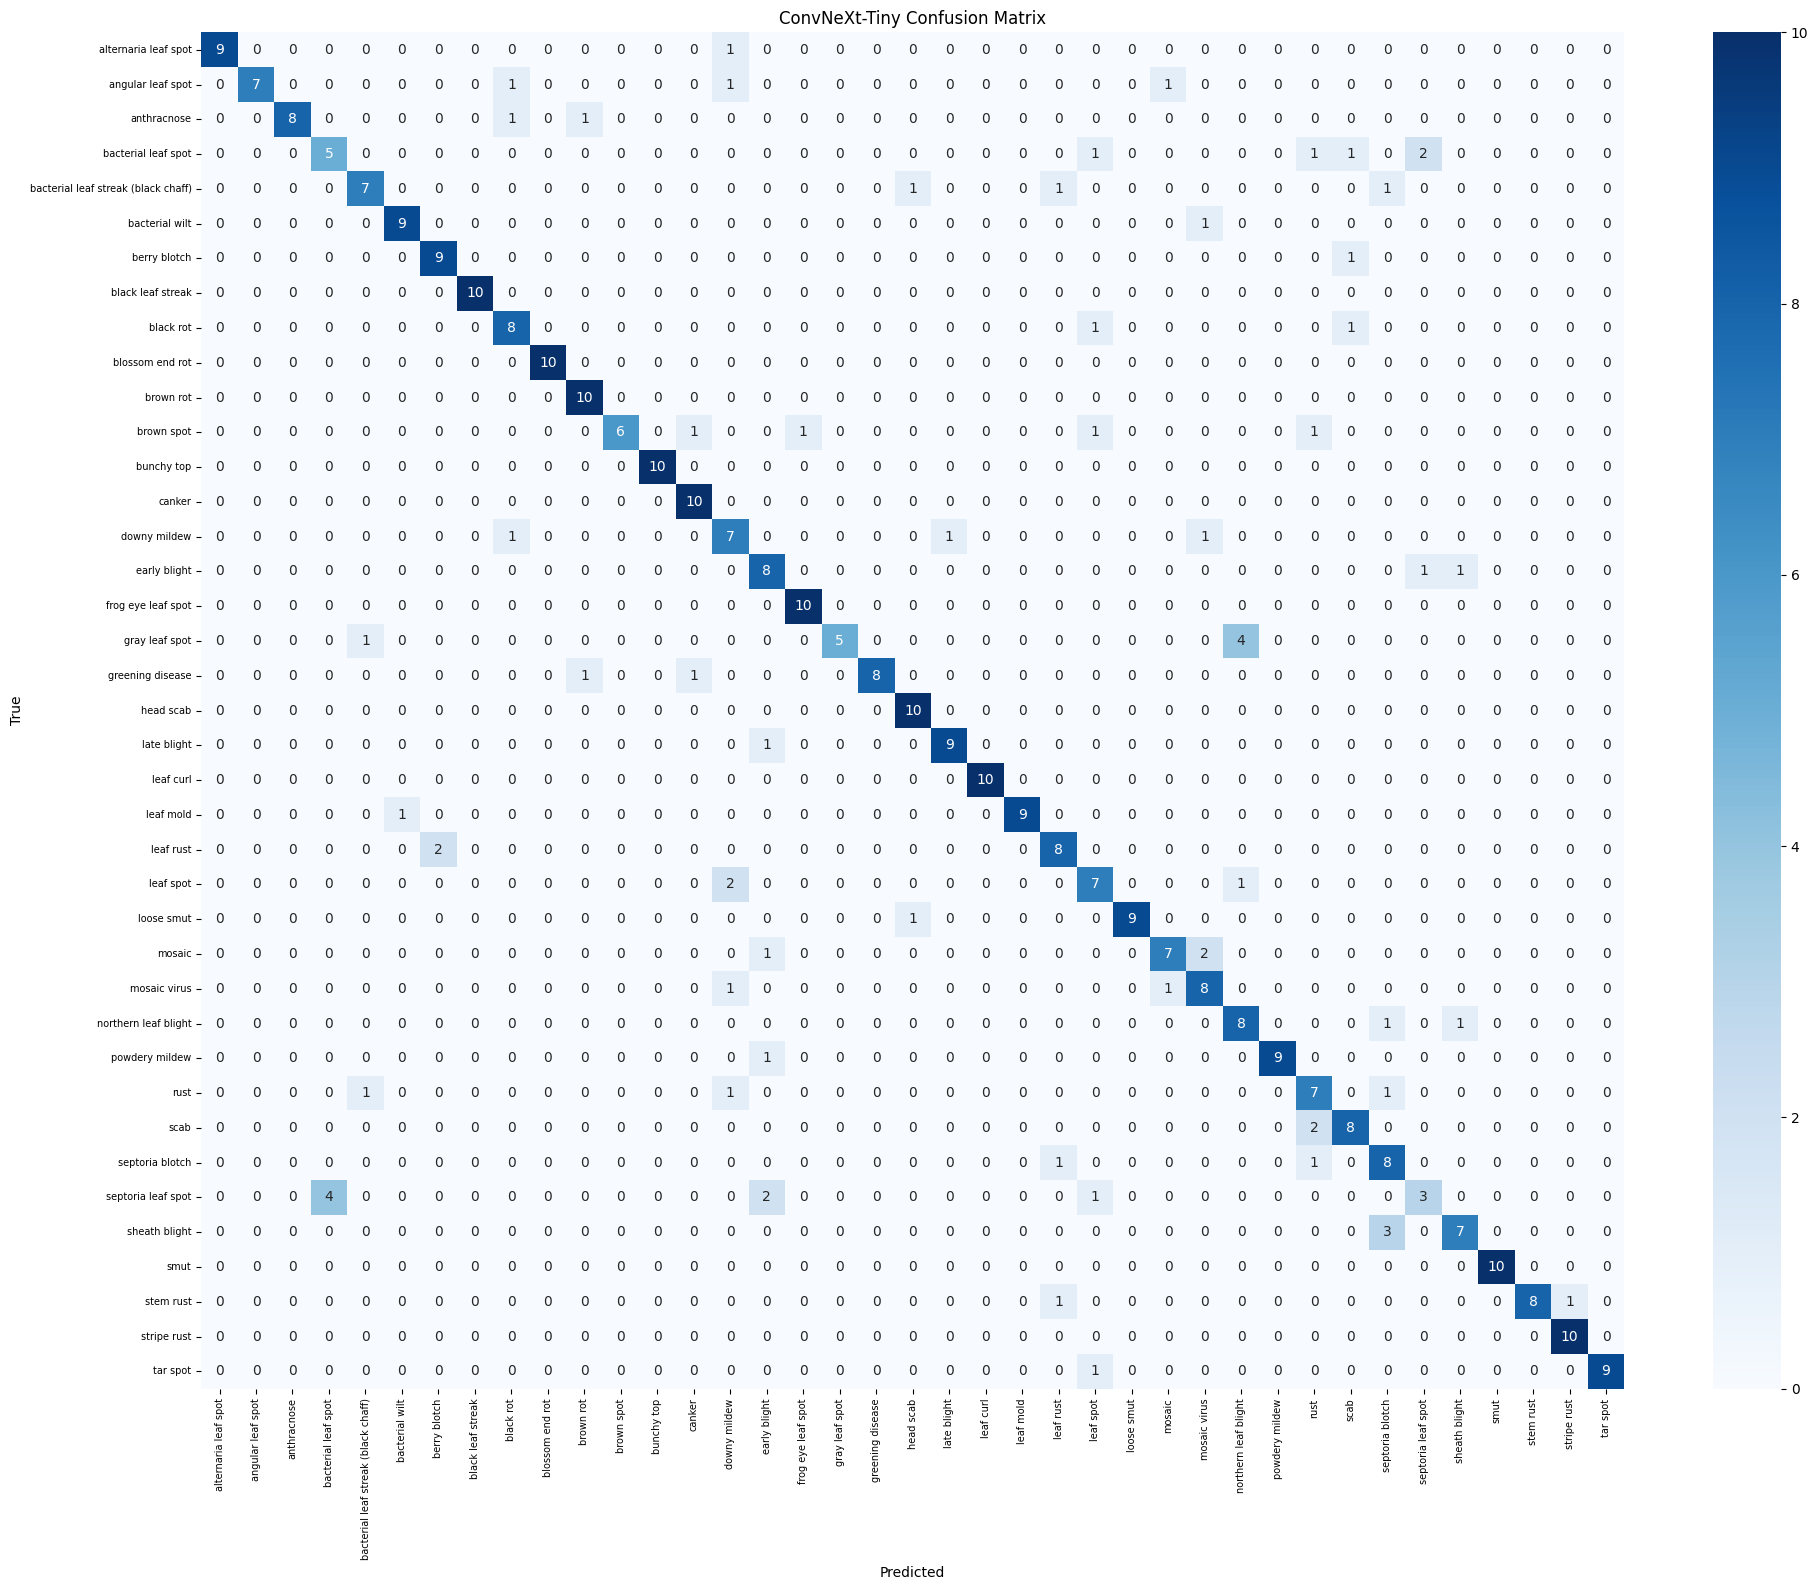

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ConvNeXt predictions from earlier evaluation
preds = all_probs.argmax(axis=1)

cm = confusion_matrix(all_labels, preds)
idx_to_disease = {v: k for k, v in label_map.items()}
disease_names = [idx_to_disease[i] for i in range(len(label_map))]

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=disease_names, yticklabels=disease_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ConvNeXt-Tiny Confusion Matrix')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/plant-disease/confusion_matrix.png', dpi=150)
plt.show()